<a href="https://colab.research.google.com/github/Shamitha018/140-basic-python-programs/blob/main/AgglomerativeClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

**Mall customer data**

- It has four columns having CustomerID, Gender , Age, Income and Spending score

- Spending score between 1 to 100

- More spending score means more valuable customer

- Income and Spending score are the important variables

- Group the data based on Income and Spending score

In [4]:
# Read the data:
data=pd.read_csv("/content/Mall_Customers.csv")
data.shape

(200, 5)

In [5]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# Select only income and Spending score columns
# select only Annual income and spending score
# M-1: select by using column names
# M-2: select by usong iloc
# M-3 : by droping unwanted columns
X=data.iloc[:,[3,4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [8]:
X.shape

(200, 2)

**Scatter plots**

In [9]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

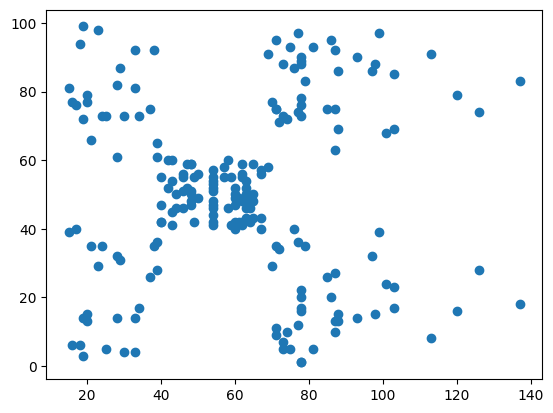

In [10]:
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'])
plt.show()

$K-Means$

**WCSS**

- From above scatter plots we observered there might be 5 optimal clusters can be available

- in order to get optimal cluster we will use **elbow method**

- elbow method is a graph between cluster vs WCSS

- so first we will calculate wcss for one cluster i.e.k=1

- then we repeat the process for multiple clutsers

- then we plot the graph

In [11]:
# We need to decide the number of clusters
# Elbow method
# Within cluster sum of squares(wcss)
# we randomly gives 10 clusters, for each cluster will calculate within sum of squares

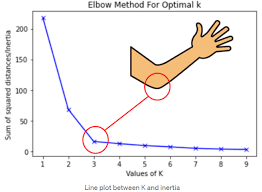

**First we Check for one cluster to understand Within sum of squares concept**

In [12]:
from sklearn.cluster import KMeans

In [13]:
### Just applying One cluster
### Base model

In [14]:
kmeans_1=KMeans(n_clusters=1,
                max_iter=300,
                random_state=1234)
kmeans_1

# n_clusters= no of clusters to choose
# max_iter= the distance calculations
# random state= picking a random observations

KMeans(n_clusters=1, random_state=1234)

In [15]:
kmeans_1.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 1,
 'n_init': 'auto',
 'random_state': 1234,
 'tol': 0.0001,
 'verbose': 0}

In [16]:
# select only Annual income and spending score
X=data.iloc[:,[3,4]]

In [17]:
kmeans_1.fit(X)

KMeans(n_clusters=1, random_state=1234)

In [18]:
from sklearn.cluster import KMeans
kmeans_1=KMeans(n_clusters=1,max_iter=300,random_state=1234)
kmeans_1.fit(X)
# we are not interested which data point
# belongs tow which cluster
# bcz here only one cluster

KMeans(n_clusters=1, random_state=1234)

$Intertia$:

- measures how well a dataset was clustered by K-Means.

- It is calculated by measuring the distance between each data point and its centroid, squaring this distance,

- and summing these squares across one cluster

- Interita also called as **Within Cluster sum of squares(WCSS)**

- Choose the clusters find the distance between each data point to the cluster centroid

- Add all the distances is nothing but WCSS

In [19]:
kmeans_1.inertia_  # Variance

269981.28000000014

In [20]:
means=kmeans_1.cluster_centers_
means

array([[60.56, 50.2 ]])

In [21]:
#X['Annual Income (k$)'].mean()

In [22]:
data['Annual Income (k$)'].mean(),data['Spending Score (1-100)'].mean()

(np.float64(60.56), np.float64(50.2))

In [23]:
#X.values

In [24]:
np.sum(np.square(X.values-means))

np.float64(269981.28)

In [25]:
############ 1 point ####################
print((15-60.56)**2)
print((39-50.2)**2)
print((15-60.56)**2+(15-60.56)**2)
#####################################
print(X.values[0])
print(means)
print(np.sum(np.square(X.values[0]-means)))


2075.7136
125.44000000000007
4151.4272
[15 39]
[[60.56 50.2 ]]
2201.1536000000046


In [26]:
summ=0
for i in X.values:
    d=np.sum(np.square(i-means))
    summ=summ+d
summ

#(15-60.56)^2+(39-50.2)^2

np.float64(269981.28000000014)

**Try to identify optimal clusters using elbow method**

In [27]:
# Read the data
# X  take only two columns
from sklearn.cluster import KMeans
kmeans_1=KMeans(n_clusters=1,
                max_iter=300,
                random_state=1234)
kmeans_1.fit(X)
kmeans_1.inertia_

269981.28000000014

In [28]:
import warnings

warnings.filterwarnings('ignore')

wss=[]
for i in range(1,21):
    kmeans=KMeans(n_clusters=i,
                  max_iter=300,
                  random_state=1234)
    kmeans.fit(X)
    wss.append(round(kmeans.inertia_,2))

In [29]:
wss

# If you are increase more clusters
# data points will be divided across the clusters
#

[269981.28,
 185140.02,
 106348.37,
 73880.64,
 44448.46,
 37233.81,
 30241.34,
 29474.65,
 23977.39,
 20792.48,
 19295.24,
 16171.41,
 14749.86,
 13905.26,
 12413.87,
 10929.42,
 10069.84,
 9603.0,
 9287.58,
 8644.85]

In [30]:
pd.DataFrame(zip(wss,range(1,21)),
            columns=['WCSS','K'])

,WCSS,K
0,269981.28,1
1,185140.02,2
2,106348.37,3
3,73880.64,4
4,44448.46,5
5,37233.81,6
6,30241.34,7
7,29474.65,8
8,23977.39,9
9,20792.48,10


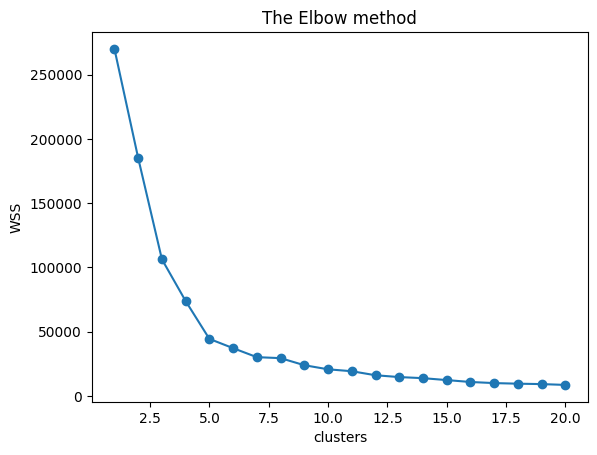

In [31]:
plt.scatter(range(1,21),wss)
plt.plot(range(1,21),wss)
plt.title("The Elbow method")
plt.xlabel("clusters")
plt.ylabel("WSS")
plt.show()

**Using elbow method we decided number of clusters are 5**

- now Read the KMeans method

- give 5 clusters

- fit is using to calculate inertia

- once we got our optimal cluters, we need to get the cluster of each data point

- for that we need to use **fit_predict**

- predict the clusters on input X

In [32]:
kmeans=KMeans(n_clusters=5,
              max_iter=300,
              random_state=1234)
y_clusters=kmeans.fit_predict(X) # which data point belongs to which cluster
y_clusters

# Here 0= cluster_1
# and 4 = cluster_5
# Python index start with zero
# y_clusters will give that
# We have 200 data points in X
# X[:3]
# income    Spending score   Cluster
# 15           39             0       c1
# 15           81             2       c3
# 16            6             0       c1


# income    Spending score   Cluster
# 15           39             pink       c1
# 15           81             Blue      c3
# 16            6             pink       c1

array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 4,
       0, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [33]:
data['Cluster_group']=y_clusters


In [34]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


In [35]:
data['Cluster_group'].value_counts()

,count
Cluster_group,
4,81
1,39
3,35
0,23
2,22


**Cluster_0**

In [36]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster_group'],
      dtype='object')

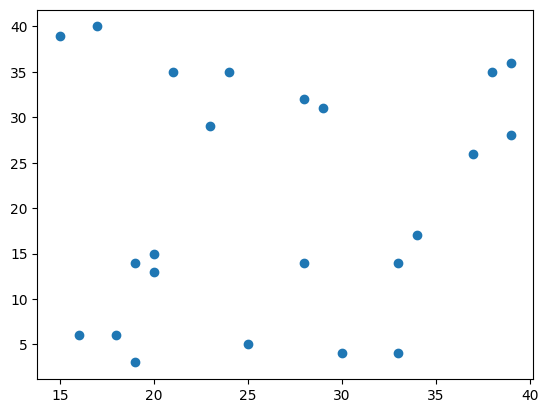

In [37]:
# 200 data points
# cluster=0   23
# I want to retrive only 23 data point
df=data[data['Cluster_group']==0]
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])

**Cluser_1**

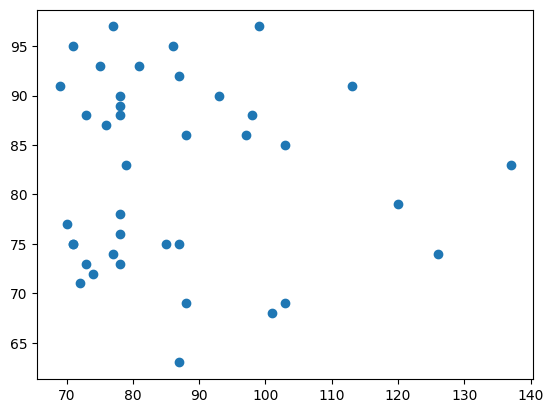

In [38]:
# 200 data points
# cluster=0   23
# I want to retrive only 23 data point
df=data[data['Cluster_group']==1]
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])

**Cluster_0 and Cluster_1**

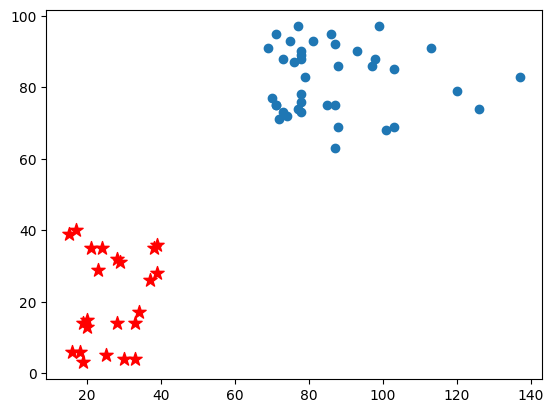

In [39]:
# 200 data points
# cluster=0   23
# I want to retrive only 23 data point
df1=data[data['Cluster_group']==0]
df2=data[data['Cluster_group']==1]
plt.scatter(df1['Annual Income (k$)'],
            df1['Spending Score (1-100)'],
            marker='*',
            c='red',
            s=100)
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'])

**groupby**

In [40]:
data.groupby('Cluster_group')
# 5 groups

In [41]:
# list(data.groupby('Cluster_group'))

In [42]:
list(data.groupby('Cluster_group'))
data.groupby('Cluster_group')['Cluster_group'].count()

,Cluster_group
Cluster_group,
0,23
1,39
2,22
3,35
4,81


In [43]:
# These are the data points which belongs to only
# Cluster=0
data[data['Cluster_group']==0].iloc[:,[3,4]]

,Annual Income (k$),Spending Score (1-100)
0,15,39
2,16,6
4,17,40
6,18,6
8,19,3
10,19,14
12,20,15
14,20,13
16,21,35
18,23,29


In [44]:
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [45]:
# Group the data points
# We calcualte mean of each cluster data points
#X[X['Cluster_group']==0].iloc[:,[0,1]]
cs_1=data[data['Cluster_group']==0].iloc[:,[3,4]]
cs_2=data[data['Cluster_group']==1].iloc[:,[3,4]]
cs_3=data[data['Cluster_group']==2].iloc[:,[3,4]]
cs_4=data[data['Cluster_group']==3].iloc[:,[3,4]]
cs_5=data[data['Cluster_group']==4].iloc[:,[3,4]]
d1={'Cluster-1':cs_1.mean(),
   'Cluster-2':cs_2.mean(),
   'Cluster-3':cs_3.mean(),
   'Cluster-4':cs_4.mean(),
   'Cluster-5':cs_5.mean()}
pd.DataFrame(d1)

,Cluster-1,Cluster-2,Cluster-3,Cluster-4,Cluster-5
Annual Income (k$),26.304348,86.538462,25.727273,88.200000,55.296296
Spending Score (1-100),20.913043,82.128205,79.363636,17.114286,49.518519


- We read the data

- We selected specific columns

- We given randomly 10 clusters

- We calculated the interia of 10 clusters

- By using elbow method , we decided 5 clusters are enough

- We pass the 5 clusters to the K-means

- We pass the data (X)  and the get cluster values for all observations

- We divided into 5 Data frames w.r.t the cluster observations

- We calculated Average income and Average spending score of each cluster observation

In [46]:
# d1=pd.DataFrame(dict(cs_1.mean()),index=['Cluster-1'])
# d2=pd.DataFrame(dict(cs_2.mean()),index=['Cluster-2'])
# d3=pd.DataFrame(dict(cs_3.mean()),index=['Cluster-3'])
# d4=pd.DataFrame(dict(cs_4.mean()),index=['Cluster-4'])
# d5=pd.DataFrame(dict(cs_5.mean()),index=['Cluster-5'])
# pd.concat[d1+d2+d3+d4+d5]

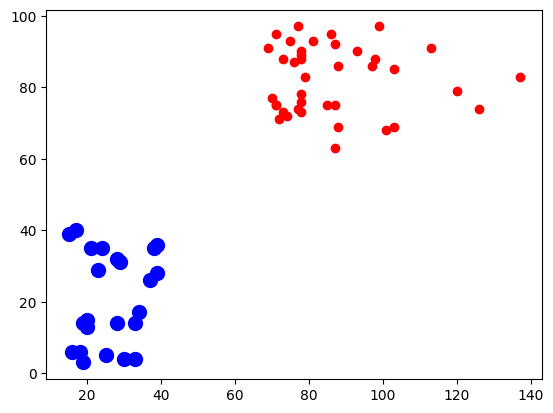

In [47]:
col1_0=data[y_clusters==0]['Annual Income (k$)']
col2_0=data[y_clusters==0]['Spending Score (1-100)']
col1_1=data[y_clusters==1]['Annual Income (k$)']
col2_1=data[y_clusters==1]['Spending Score (1-100)']
plt.scatter(col1_0,col2_0,s=100,c='blue')
plt.scatter(col1_1,col2_1,c='red')

In [48]:
X[y_clusters==0] # two columns values which are belongs to cluster =0
# Out of these two columns we need seperate col1 values and col2 values

c1=X[y_clusters==0,0]  # First columns values belongs to clsuter =0
c2=X[y_clusters==0,1]
plt.scatter(c1,c2,s=1000,c='red')
#for the scatter plot
#plt.scatter(col1,col2)

InvalidIndexError: (array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,


In [49]:
X[y_clusters==0,1]

InvalidIndexError: (array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,


In [ ]:
# X[:,0]  # O  fisrt column values
# X[:,1]  # 1  second column values
# plt.scatter(X[:,0],X[:,1])

# (X[y_clusters==0,0],X[y_clusters==0,1]
# (X[y_clusters==1,0],X[y_clusters==1,1]
# (X[y_clusters==3,0],X[y_clusters==3,1]
# (X[y_clusters==2,0],X[y_clusters==2,1]
# (X[y_clusters==4,0],X[y_clusters==4,1]

X[y_clusters]

 0   1
[15,39]========= > 0

0,0 ======= 15
0,1 ======= 39


y_clusters=0,0 ======= > first 0 represnts cluster

               ======= > second 0 represnts first column
               
    
y_clusters=0,1 ======= > first 0 represnts cluster

               ======= > second term 1 represnts second column
    

========= zero cluster with first column (0,0)

========= zero cluster with second column (0,1)

========= First cluster with first column (1,0)

========= First cluster with second column (1,1)

========= second cluster with first column (2,0)

========= second cluster with second column (2,1)

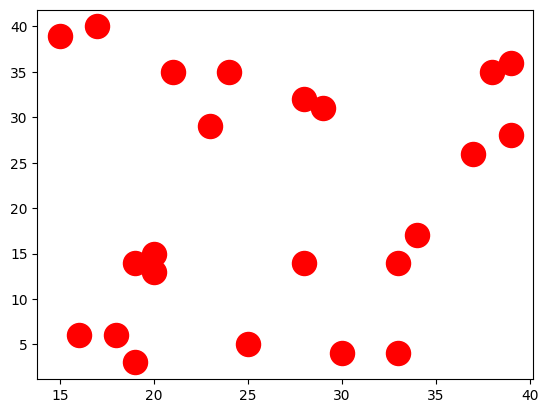

In [50]:
X=data.iloc[:,[3,4]].values
X[y_clusters==0] # cluster 0 obeservations
len(X[y_clusters==0])
l1=X[y_clusters==0,0] # first column
l2=X[y_clusters==0,1] # second
plt.scatter(l1,l2,s=300,c='red')

In [51]:
#I want to extract the data based on clusters
X=data.iloc[:,[3,4]].values
len(X[y_clusters==0]),len(X[y_clusters==1]),len(X[y_clusters==2])

(23, 39, 22)

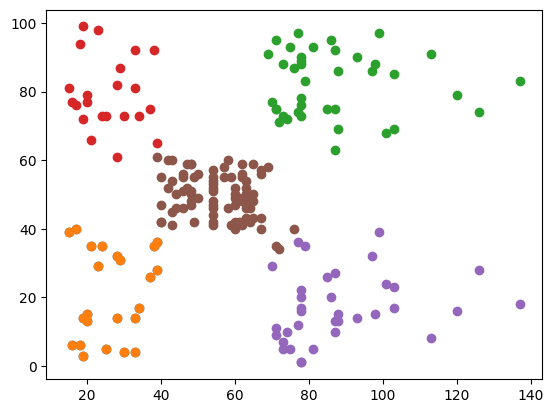

In [52]:
# X has two
X=data.iloc[:,[3,4]].values
col1=X[y_clusters==0][:,0]
col2=X[y_clusters==0][:,1]
plt.scatter(col1,col2)

plt.scatter(X[y_clusters==0][:,0],X[y_clusters==0][:,1])
plt.scatter(X[y_clusters==1][:,0],X[y_clusters==1][:,1])
plt.scatter(X[y_clusters==2][:,0],X[y_clusters==2][:,1])
plt.scatter(X[y_clusters==3][:,0],X[y_clusters==3][:,1])
plt.scatter(X[y_clusters==4][:,0],X[y_clusters==4][:,1])

In [53]:
# sctter plot
# (Annulaincome,Spendingscore)
X=data.iloc[:,[3,4]].values  # two columns
X[y_clusters==0,0] # Cluster 0 only Annula income
X[y_clusters==0,1] # Spending score
############################################
X[y_clusters==1,0]  # cluster=1  with first column
X[y_clusters==1,1]  # cluster=1  with second column

array([91, 77, 95, 75, 75, 71, 88, 73, 72, 93, 87, 97, 74, 90, 88, 76, 89,
       78, 73, 83, 93, 75, 95, 63, 75, 92, 86, 69, 90, 86, 88, 97, 68, 85,
       69, 91, 79, 74, 83])

In [57]:
#======= Dataframe ==========
X # Dataframe
col1=X[y_clusters==0].iloc[:,0]
col2=X[y_clusters==0].iloc[:,1]

#====== Array of values =========
X=X.values
col1=X[y_clusters==0,0]
col2=X[y_clusters==0,1]
plt.scatter(col1,col2)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

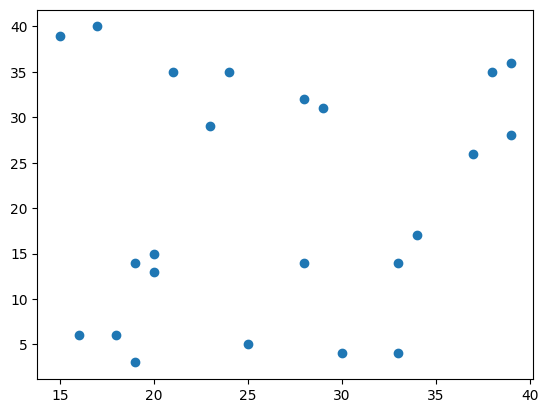

In [56]:
X=data.iloc[:,[3,4]].values
plt.scatter(X[y_clusters==0,0],X[y_clusters==0,1])

In [58]:
kmeans.cluster_centers_

array([[26.30434783, 20.91304348],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [55.2962963 , 49.51851852]])

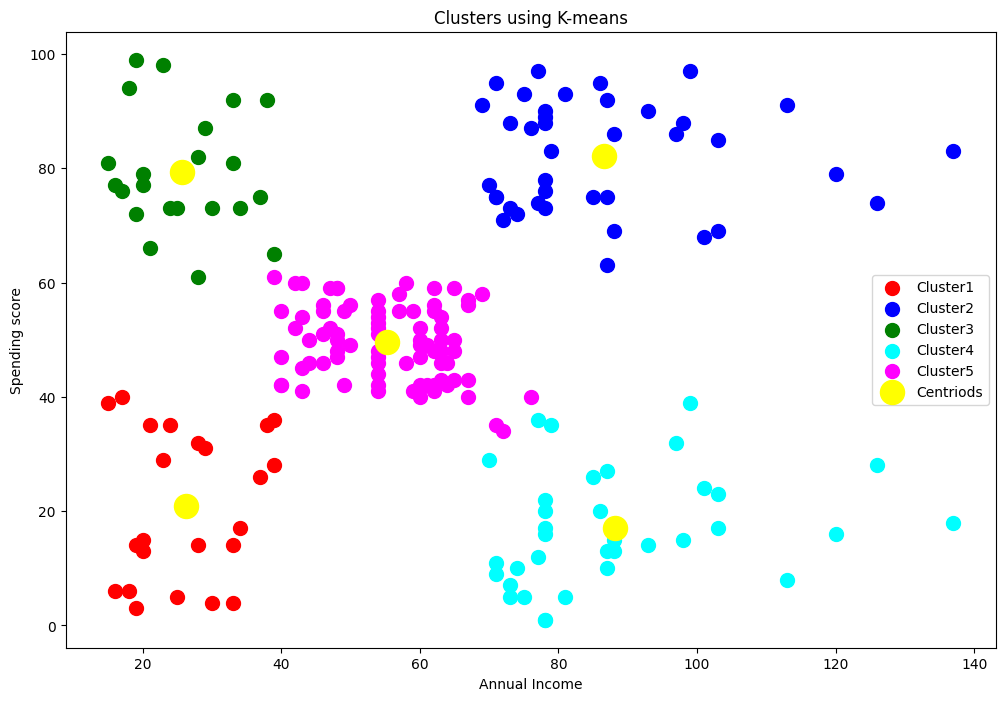

In [59]:
# Visulaize the clusters
# We are applying scatter plot between income and spending score w.r.t to clusters
X=data.iloc[:,[3,4]].values
plt.figure(figsize=(12,8))
plt.scatter(X[y_clusters==0,0],X[y_clusters==0,1],s=100,c='red',label="Cluster1")
plt.scatter(X[y_clusters==1,0],X[y_clusters==1,1],s=100,c='blue',label="Cluster2")
plt.scatter(X[y_clusters==2,0],X[y_clusters==2,1],s=100,c='green',label="Cluster3")
plt.scatter(X[y_clusters==3,0],X[y_clusters==3,1],s=100,c='cyan',label="Cluster4")
plt.scatter(X[y_clusters==4,0],X[y_clusters==4,1],s=100,c='magenta',label="Cluster5")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',
            label='Centriods')
plt.title("Clusters using K-means")
plt.xlabel("Annual Income")
plt.ylabel("Spending score")
plt.legend()
plt.show()

# Where s will give the size of the centriod

## silhouette_score

In [60]:
import pandas as pd
data=pd.read_csv("Mall_Customers.csv")
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

<img src="https://miro.medium.com/v2/resize:fit:960/1*N3Xm52bELqrju_DWLqjyHg.jpeg" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 960px; height: 222px; margin: 0px; width: 395px;" alt="Understanding Silhouette Score in Clustering | by FARSHAD K | Medium" jsname="kn3ccd">

In [67]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

data=pd.read_csv("Mall_Customers.csv")
X=data[['Annual Income (k$)','Spending Score (1-100)']].values
kmeans = KMeans(n_clusters=5)
y=kmeans.fit_predict(X)
# kmeans.labels_
kmeans.fit(X)

KMeans(n_clusters=5)

In [62]:
kmeans.labels_

array([3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1,
       3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 0, 4, 1, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4], dtype=int32)

In [63]:
kmeans.fit_predict(X)

array([3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 4,
       3, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 1, 0, 4, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 4, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

**unseen data**

In [64]:
kmeans.predict([[10,60]])

array([2], dtype=int32)

In [65]:
y_clusters

array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 4,
       0, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [68]:
y

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4,
       1, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 3, 2, 4, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [69]:
silhouette_score(X,kmeans.labels_)
# Overall score

np.float64(0.553931997444648)

In [70]:
from sklearn.metrics import silhouette_score,silhouette_samples
sample_silouthe=silhouette_samples(X,kmeans.labels_)
# Observation wise score
sample_silouthe

array([ 0.41700493,  0.69637752,  0.6399526 ,  0.6964831 ,  0.39230007,
        0.6981303 ,  0.64910316,  0.65972193,  0.63021343,  0.66350398,
        0.67788678,  0.62355268,  0.68003912,  0.71908624,  0.68070792,
        0.72573786,  0.48557434,  0.54505971,  0.58062414,  0.631684  ,
        0.46597803,  0.6774284 ,  0.64167396,  0.67170097,  0.66126882,
        0.70488566,  0.48931822,  0.30121073,  0.49570828,  0.6847372 ,
        0.60630845,  0.612474  ,  0.57697817,  0.61775968,  0.60922585,
        0.63936997,  0.58581667,  0.52897452,  0.42116018,  0.48378692,
        0.09342298,  0.54589636, -0.00927769,  0.1170758 ,  0.31116673,
        0.0507214 ,  0.38841392,  0.43312564,  0.29204034,  0.29204034,
        0.5203998 ,  0.30155503,  0.51561237,  0.34144075,  0.48988757,
        0.37332421,  0.59860522,  0.54128572,  0.63883859,  0.59367906,
        0.55806656,  0.57952023,  0.64920886,  0.50415514,  0.67809813,
        0.52881485,  0.68358333,  0.66547762,  0.52881485,  0.65

In [71]:
import numpy as np
# min_val=np.min(sample_silouthe)
# sample_silouthe.tolist().index(min_val)

np.argmin(sample_silouthe) # min value of index 132
np.argmax(sample_silouthe) # 92
np.mean(sample_silouthe)   # match with overall score

np.float64(0.553931997444648)

In [72]:
silouthe_df=pd.DataFrame(zip(kmeans.labels_,sample_silouthe),
            columns=['Cluster','Silouthe'])
silouthe_df.values[[132,92]]

array([[0.        , 0.11529355],
       [0.        , 0.75806935]])

In [73]:
# Individual cluster silouthe score
silouthe_df.groupby('Cluster')['Silouthe'].mean()

,Silouthe
Cluster,
0,0.596651
1,0.512268
2,0.503987
3,0.599013
4,0.509171


In [74]:
silouthe_df=pd.DataFrame(zip(kmeans.labels_,sample_silouthe),
            columns=['Cluster','Silouthe'])
silouthe_df.groupby('Cluster')['Silouthe'].mean()
# Clsuter wise score

,Silouthe
Cluster,
0,0.596651
1,0.512268
2,0.503987
3,0.599013
4,0.509171


- Silhoutte score will give an idea of how the choosen clusters are well sepearated

- In above problem we chossen 5 clusters

- and silouthe score is 0.55

- The chosen clusters moderately sepearted or well sepearted , we can find by applying simpliar

    analysis on different different clusters



In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

data=pd.read_csv("Mall_Customers.csv")
X=data[['Annual Income (k$)','Spending Score (1-100)']].values
# Initialize lists to store silhouette scores for each k
silhouette_scores = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Find the optimal k value that maximizes silhouette score
print(silhouette_scores)
k_values=range(2,11)


[np.float64(0.37845852273501307), np.float64(0.46761358158775435), np.float64(0.4937945814354117), np.float64(0.46238415290734225), np.float64(0.5379675585622219), np.float64(0.4104044036490344), np.float64(0.4581145811914651), np.float64(0.4592339450478494), np.float64(0.4509769704777274)]


In [76]:
pd.DataFrame(zip(k_values,silhouette_scores),columns=['Cluster','Silhothe score'])

,Cluster,Silhothe score
0,2,0.378459
1,3,0.467614
2,4,0.493795
3,5,0.462384
4,6,0.537968
5,7,0.410404
6,8,0.458115
7,9,0.459234
8,10,0.450977


In [77]:
list(k_values)

[2, 3, 4, 5, 6, 7, 8, 9, 10]

In [78]:
np.max(silhouette_scores)
ID=np.argmax(silhouette_scores)
k_values[ID]

6

In [79]:
optimal_k = k_values[np.argmax(silhouette_scores)]
optimal_silhouette_score = max(silhouette_scores)

print("Optimal number of clusters:", optimal_k)
print("Optimal silhouette score:", optimal_silhouette_score)


Optimal number of clusters: 6
Optimal silhouette score: 0.5379675585622219


In [80]:
print(list(k_values))
k_values[np.argmax(silhouette_scores)]

[2, 3, 4, 5, 6, 7, 8, 9, 10]


6

In [81]:
k_values[silhouette_scores.index(max(silhouette_scores))]
# we are getting maximum value
# we are getting the index of the maximum value
# that index we are passing into cluster list
# For which cluster what is the maximu silhoutte score

6

- np.max  will give the maximum value

- np.argmax will give index of the maximum value

In [82]:
np.argmax(silhouette_scores)


np.int64(4)

In [83]:
silhouette_scores.index(max(silhouette_scores))  # one method
print("the index of maximum value is:",np.argmax(silhouette_scores))
print("the maximum value is:",np.max(silhouette_scores))
k_values=range(2,11) # [2,3,4,5,6,7,8,9,10,11]
k_values[3]

# fisrt get the max values
# second get the index of the max value
# pass that index inthe list of cluster values ==== >5

the index of maximum value is: 4
the maximum value is: 0.5379675585622219


5

$Hierarchical$ $Cluster$

In [84]:
# Import the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Read the data:
data=pd.read_csv("Mall_Customers.csv")

X=data.iloc[:,[3,4]].values


In [85]:
import scipy.cluster.hierarchy as sch

**Linkage functions**

- Every observation consider as one cluster

- Based on symmetry matrix we form the groups

- Linkage functions

    - Simple linkage : Less distance that means more realtion
    
    - Complete linkage : Max distance that means less realtion
    
    - Average Ward Method

In [86]:
import scipy.cluster.hierarchy as sch
val=[[2,5],[3,6],[7,10],[12,10],[6,3],[10,20]]
sch.linkage(val)

array([[ 0.        ,  1.        ,  1.41421356,  2.        ],
       [ 4.        ,  6.        ,  4.24264069,  3.        ],
       [ 2.        ,  3.        ,  5.        ,  2.        ],
       [ 7.        ,  8.        ,  5.65685425,  5.        ],
       [ 5.        ,  9.        , 10.19803903,  6.        ]])

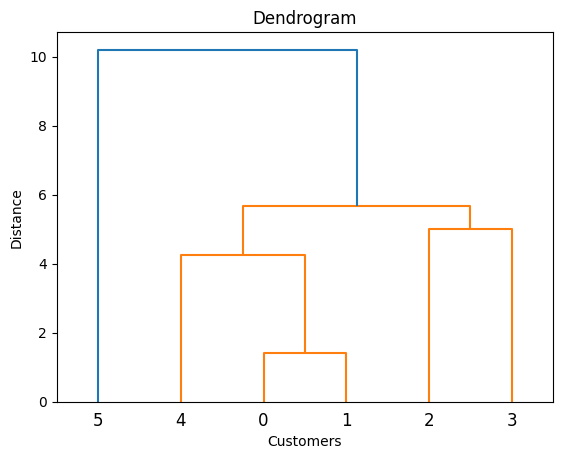

In [87]:
import matplotlib.pyplot as plt
dendogram=sch.dendrogram(sch.linkage(val,method='single'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

val=[[2,5],[3,6],[7,10],[12,10],[6,3],[10,20]]

In [88]:
sch.linkage(X,method='single')

array([[ 48.        ,  49.        ,   0.        ,   2.        ],
       [ 65.        ,  68.        ,   0.        ,   2.        ],
       [156.        , 158.        ,   0.        ,   2.        ],
       [129.        , 131.        ,   0.        ,   2.        ],
       [ 67.        ,  69.        ,   1.        ,   2.        ],
       [ 64.        ,  66.        ,   1.        ,   2.        ],
       [ 60.        ,  61.        ,   1.        ,   2.        ],
       [ 63.        , 201.        ,   1.        ,   3.        ],
       [ 51.        ,  53.        ,   1.        ,   2.        ],
       [ 74.        ,  77.        ,   1.        ,   2.        ],
       [ 85.        , 209.        ,   1.        ,   3.        ],
       [ 79.        ,  82.        ,   1.        ,   2.        ],
       [ 78.        ,  80.        ,   1.        ,   2.        ],
       [ 76.        , 212.        ,   1.        ,   3.        ],
       [ 75.        , 213.        ,   1.        ,   4.        ],
       [ 81.        , 214

In [89]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

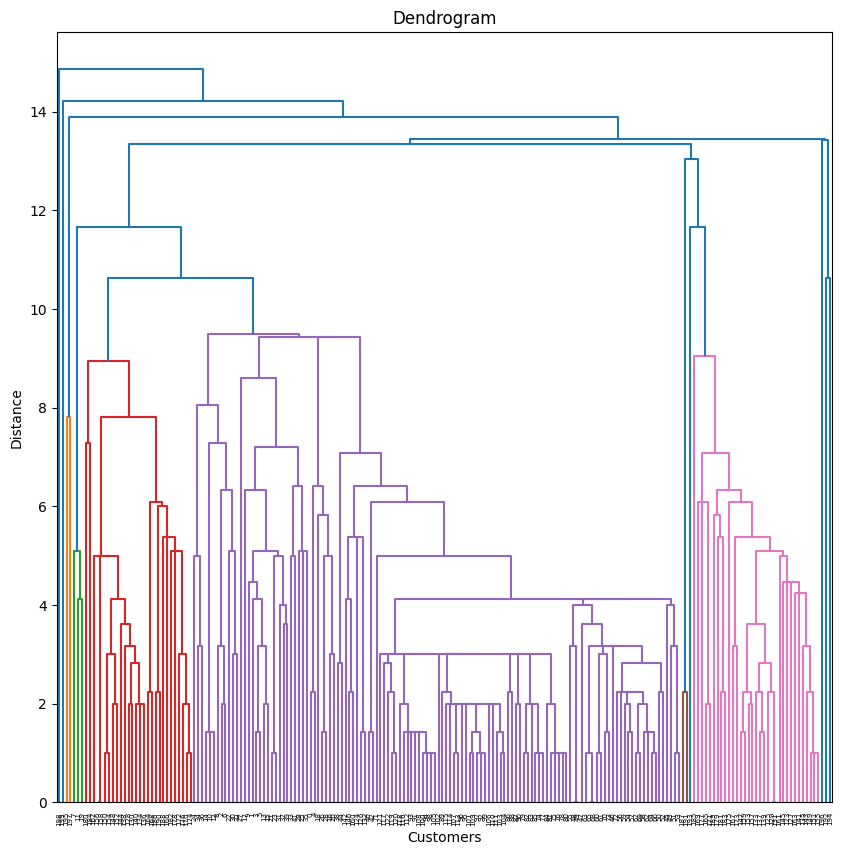

In [90]:
# Dendogram using Single
plt.figure(figsize=(10,10))
dendogram=sch.dendrogram(sch.linkage(X,method='single'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

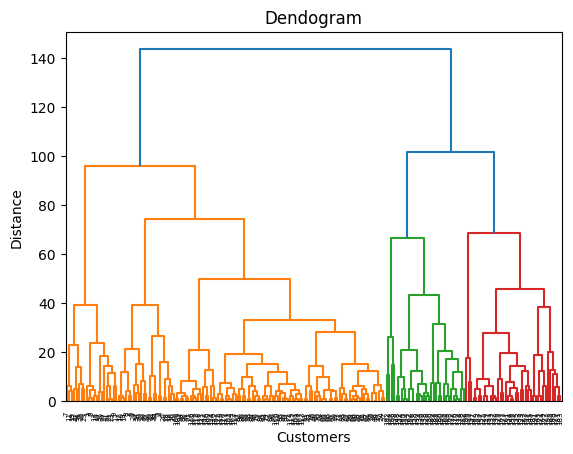

In [91]:
dendogram=sch.dendrogram(sch.linkage(X,method='complete'))
plt.title("Dendogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

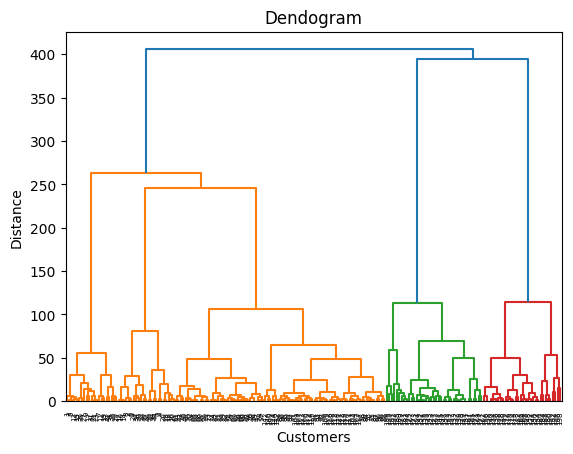

In [92]:
dendogram=sch.dendrogram(sch.linkage(X,method='ward'))
plt.title("Dendogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

- single linkage is used to when data is irregular shape

    - Analogy: In a classroom all the students stay together by holding hands

    - Minimum distance

- Complete linkage is used to if we want to well seperate all the data points

    - In a classroom every student is form a group

    - each group maintain a distance

- Ward method works based on wcss(inertia) mainly on numerical columns

    - Students forms group those student are happy

In [ ]:
#Method-2

In [93]:
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings("ignore")
hc=AgglomerativeClustering(n_clusters=5,
                           #affinity='euclidean', # shift+tab write the correct one
                           metric='euclidean',
                           linkage='ward')
y_hc=hc.fit_predict(X)
y_hc

# Those who are getting error affinity
# metric='euclidean'



# cluster number might be different
# but grouping is correct

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [94]:
y_hc # kmeans cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [95]:
k-means ======= > 1 sample , 3rd sample ======= > 0
hch =========== > 1 sample , 3rd sample ======= > 4

SyntaxError: invalid decimal literal (1077415066.py, line 1)

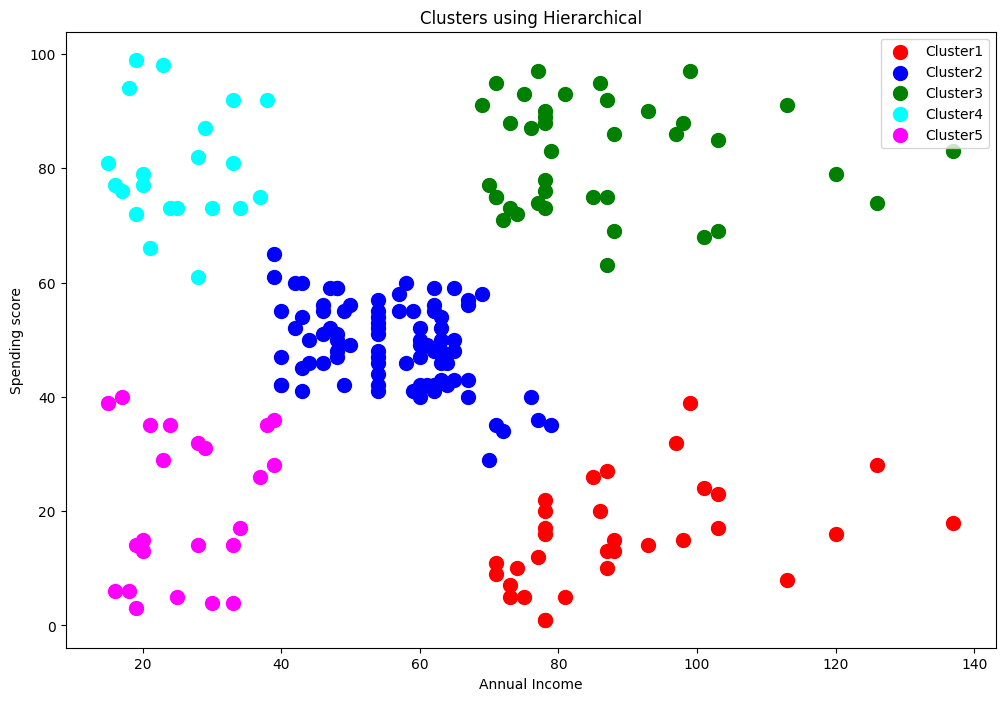

In [96]:
# Visulaize the clusters
# We are applying scatter plot between income and spending score w.r.t to clusters
plt.figure(figsize=(12,8))
plt.scatter(X[y_hc==0,0],X[y_hc==0,1],s=100,c='red',label="Cluster1")
plt.scatter(X[y_hc==1,0],X[y_hc==1,1],s=100,c='blue',label="Cluster2")
plt.scatter(X[y_hc==2,0],X[y_hc==2,1],s=100,c='green',label="Cluster3")
plt.scatter(X[y_hc==3,0],X[y_hc==3,1],s=100,c='cyan',label="Cluster4")
plt.scatter(X[y_hc==4,0],X[y_hc==4,1],s=100,c='magenta',label="Cluster5")
#plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label='Centriods')
plt.title("Clusters using Hierarchical")
plt.xlabel("Annual Income")
plt.ylabel("Spending score")
plt.legend()
plt.show()

In [ ]:
Ridge
lasso
elastic
